In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%%time
adata = sc.read_h5ad("06C_final_adata_for_UCSC.h5ad")
adata

CPU times: user 10.4 s, sys: 60 s, total: 1min 10s
Wall time: 1min 11s


AnnData object with n_obs × n_vars = 2275105 × 16115
    obs: 'age', 'donor_id', 'sex', 'disease', 'consistent_cell_type', 'study', 'technology', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'age_group', 'final_cell_type', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'cell_type_plus_subcluster'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'age_disease_colors', 'cell_type_plus_subcluster_colors', 'final_cell_type_colors', 'log1p', 'neighbors', 'study_colors', 'umap', 'v2_scvi_cell_type_colors'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [3]:
def subsample_adata_by_group(adata, group_key, target_n, random_state=0):
    np.random.seed(random_state)

    groups = adata.obs[group_key].value_counts(normalize=True)
    total_n = adata.n_obs

    print(f"Total cells: {total_n}")
    print(f"Target cells: {target_n}")

    subsampled_idx = []

    for g, frac in groups.items():
        cells = np.where(adata.obs[group_key].values == g)[0]
        n_group = len(cells)

        n_sub = int(np.round(frac * target_n))
        n_sub = min(n_sub, n_group)

        print(f"{g}: {n_group} to {n_sub}")

        chosen = np.random.choice(cells, size=n_sub, replace=False)
        subsampled_idx.append(chosen)

    subsampled_idx = np.concatenate(subsampled_idx)
    np.random.shuffle(subsampled_idx)

    return adata[subsampled_idx].copy()

In [4]:
#adata.obs

In [5]:
%%time
adata_sub = subsample_adata_by_group(
    adata,
    group_key="cell_type_plus_subcluster",
    target_n=400000,
    random_state=42
)

Total cells: 2275105
Target cells: 400000
Cardiomyocyte:Other: 204294 to 35918
Fibroblast:ND_enriched: 161552 to 28403
Cardiomyocyte:Metabolic: 136961 to 24080
Pericyte:Other: 123431 to 21701
Fibroblast:DCM_HCM_enriched: 120274 to 21146
Cardiomyocyte:Fetal_enriched_metabolic: 106368 to 18701
Endothelial:Capillary_2: 97270 to 17102
Myeloid:Resident: 89897 to 15805
Fibroblast:Interstitial: 85380 to 15011
Pericyte:Regulatory: 77104 to 13556
Myeloid:Monocyte_derived: 76649 to 13476
Cardiomyocyte:DCM_HCM_enriched: 76581 to 13464
Endothelial:Capillary_1: 70917 to 12468
Cardiomyocyte:Stressed: 69137 to 12155
Cardiomyocyte:Fetal_enriched_conduction: 66620 to 11713
Fibroblast:Activated: 58148 to 10223
Endothelial:Arterial: 54904 to 9653
Endothelial:Venous: 54772 to 9630
Fibroblast:Perivascular: 50500 to 8879
Fibroblast:Anti_fibrotic: 49748 to 8746
Myeloid:Resident-scavenging: 39612 to 6964
vSMC:Pericyte-like: 31651 to 5565
Lymphoid:T_cytotoxic: 30225 to 5314
Myeloid:Metabolic: 22432 to 3944
vSM

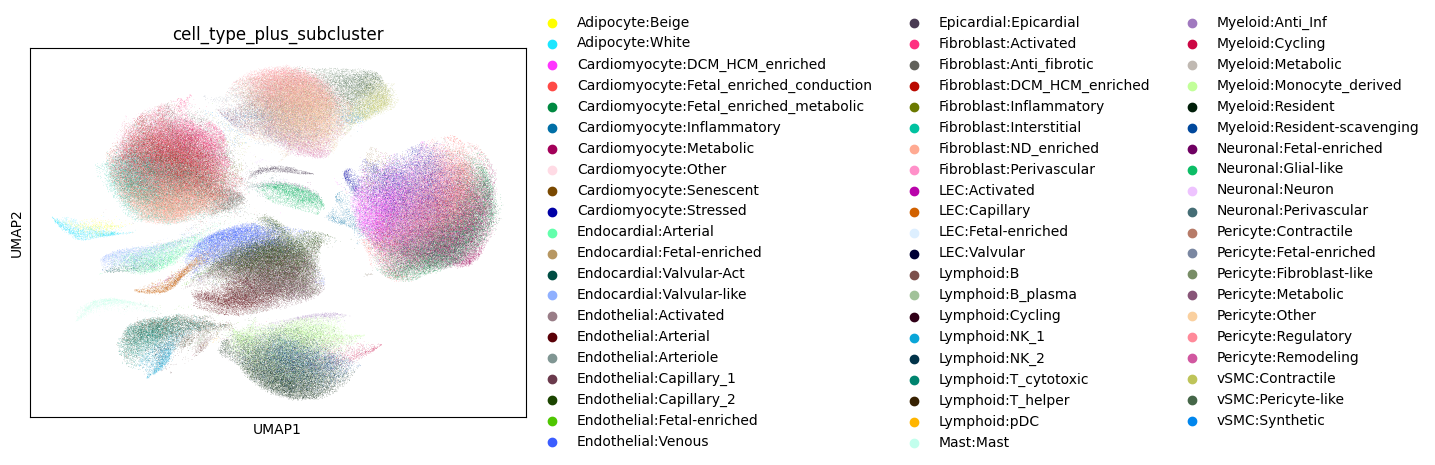

CPU times: user 2.45 s, sys: 203 ms, total: 2.65 s
Wall time: 2.46 s


In [6]:
%%time
sc.pl.umap(adata_sub, color = "cell_type_plus_subcluster")

In [ ]:
%%time
adata_sub.write("06E_subsampled_UCSC_RNA_adata.h5ad")